In [37]:

import numpy as np
import matplotlib.pyplot as plt
import h5py
import networkx as nx
import math

In [2]:
def butter_bandpass(data, fs, filt_freq, order):
    # make sure that the user provides two frequencies for bandpass filter
    try:
        # renormalize frequencies in Hz to fractional scale required by butter
        nyq = 0.5 * fs # nyquist frequency
        f0 = (filt_freq[0]/nyq)
        f1 = (filt_freq[1]/nyq)

        # highpass first
        sos = butter(order, f0, btype = 'high', analog=False, output='sos')
        y = sosfiltfilt(sos, data)

        # then lowpass
        sos = butter(order, f1, btype = 'low', analog=False, output='sos')
        y = sosfiltfilt(sos, y)
        
        return y
    
    except:
        print("filt_freq must have two frequencies for a bandpass filter")

In [79]:
def visualize_hdf5_structure(h5_object, parent_node=None, graph=None, depth=0, visited=None):
    if graph is None:
        graph = {}
    if visited is None:
        visited = set()
    
    for key, value in h5_object.items():
        # Add the current key and its attributes to the graph
        if isinstance(value, h5py.Dataset):
            attributes = dict(value.attrs)
            graph[key] = {'attributes': attributes}
        else:
            graph[key] = {}
        
        # Add an edge from the parent node to the current node
        if parent_node is not None:
            graph[parent_node].setdefault('children', []).append(key)
        
        # Check if the current node has been visited
        if key in visited:
            continue
        
        # Mark the current node as visited
        visited.add(key)
        
        # Recursively explore groups
        if isinstance(value, h5py.Group) and key != 'Anatomical data': 
            #ignore the anatomical data group for the visualizations - it creates a recursive loop
            visualize_hdf5_structure(value, key, graph, depth + 1, visited)
    
    return graph


In [80]:
def find_sampling_rate(h5_object, path=''):
    for key, value in h5_object.items():
        # Check if the current object is a dataset
        if isinstance(value, h5py.Dataset):
            # Check if 'sampling_rate' or 'rate' is present in the attributes
            if 'sampling_rate' in value.attrs:
                return path + '/' + key, value.attrs['sampling_rate']
            elif 'rate' in value.attrs:
                return path + '/' + key, value.attrs['rate']
        # Recursively search in groups
        elif isinstance(value, h5py.Group):
            result = find_sampling_rate(value, path + '/' + key)
            if result:
                return result
    # If not found, return None
    return None

In [81]:
# Function to print the tree structure iteratively
def print_tree(graph, root):
    stack = [(root, 0)]
    while stack:
        node, indent = stack.pop()
        attributes = graph[node].get('attributes', {})
        print(' ' * indent + node, attributes)
        children = graph[node].get('children', [])
        for child in reversed(children):
            if child in graph:
                stack.append((child, indent + 2))
            else:
                print(' ' * (indent + 2) + child + " (Leaf Node)")


In [82]:
#Function to visualize the graph
def draw_graph(graph):
    G = nx.DiGraph()
    for node, data in graph.items():
        attributes = data.get('attributes', {})
        G.add_node(node, label=node, **attributes)  # Ensure label=node
        children = data.get('children', [])
        for child in children:
            G.add_edge(node, child)
    
    # Using graphviz_layout with 'dot' program for hierarchical layout
    pos = nx.drawing.nx_agraph.graphviz_layout(G, prog='dot')
    
    plt.figure(figsize=(15, 10))  # Increase figure size
    nx.draw(G, pos, with_labels=False, node_size=300, node_color='skyblue')  # Disable labels for now
    
    labels = nx.get_node_attributes(G, 'label')
    label_pos = {}  # Dictionary to store label positions
    
    for node, (x, y) in pos.items():
        label_pos[node] = (x, y + 10)  # Adjust y-coordinate to move labels up
    
    # Draw labels with specified positions and rotations
    for node, (x, y) in label_pos.items():
        angle = math.degrees(math.atan2(y, x))  # Calculate angle of label
        if angle > 90:
            angle = angle - 150
        plt.text(x, y, labels[node], fontsize=8, rotation=angle, ha='center', va='center')
    
    plt.title("Hierarchical Structure of NWB File")
    plt.show()

In [83]:
"""
#get patch fs fot that cell
patch_fs = all_patch_fs[cell_num]
patch_one_ms = float(patch_fs/1000)
#get patch data 
patch_recording = np.fromfile(recfile, dtype='float64')
patch_recording = np.asarray(patch_recording)
#patch_recording = -patch_recording # positive up


patch_times = np.arange(0, np.shape(patch_recording)[0]) / patch_one_ms # in ms instead of sec


# filter the patch data
patch_filt = butter_bandpass(patch_recording, fs=patch_fs, filt_freq=[10, 25000], order=4)"""

"\n#get patch fs fot that cell\npatch_fs = all_patch_fs[cell_num]\npatch_one_ms = float(patch_fs/1000)\n#get patch data \npatch_recording = np.fromfile(recfile, dtype='float64')\npatch_recording = np.asarray(patch_recording)\n#patch_recording = -patch_recording # positive up\n\n\npatch_times = np.arange(0, np.shape(patch_recording)[0]) / patch_one_ms # in ms instead of sec\n\n\n# filter the patch data\npatch_filt = butter_bandpass(patch_recording, fs=patch_fs, filt_freq=[10, 25000], order=4)"

In [84]:
file_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/primate_recordings/M03_MW_A1_C16.nwb'

### Load files and inspect NWB structure
#### Get sampling rate info - 20kHz

In [85]:
# Open the NWB file
with h5py.File(file_path, 'r') as file:
    # Visualize the structure starting from the root
    graph = visualize_hdf5_structure(file)

In [86]:
# Print the tree structure starting from the first key
for key in graph.keys():
    print_tree(graph, key)

acquisition {}
  Sweep_0 {}
    bias_current {}
    bridge_balance {}
    capacitance_compensation {}
    data {'conversion': 1.0, 'resolution': -1.0, 'unit': 'mV'}
    electrode {'description': 'Column for storing the reference to the intracellular electrode', 'namespace': 'hdmf-common', 'neurodata_type': 'VectorData', 'object_id': '1bf4f4a2-0fb8-4be4-b7e6-dfcafced49e0'}
    starting_time {'rate': 20000.0, 'unit': 'seconds'}
  Sweep_1 {}
    bias_current {}
    bridge_balance {}
    capacitance_compensation {}
    data {'conversion': 1.0, 'resolution': -1.0, 'unit': 'mV'}
    electrode {'description': 'Column for storing the reference to the intracellular electrode', 'namespace': 'hdmf-common', 'neurodata_type': 'VectorData', 'object_id': '1bf4f4a2-0fb8-4be4-b7e6-dfcafced49e0'}
    starting_time {'rate': 20000.0, 'unit': 'seconds'}
  Sweep_10 {}
    bias_current {}
    bridge_balance {}
    capacitance_compensation {}
    data {'conversion': 1.0, 'resolution': -1.0, 'unit': 'mV'}
    

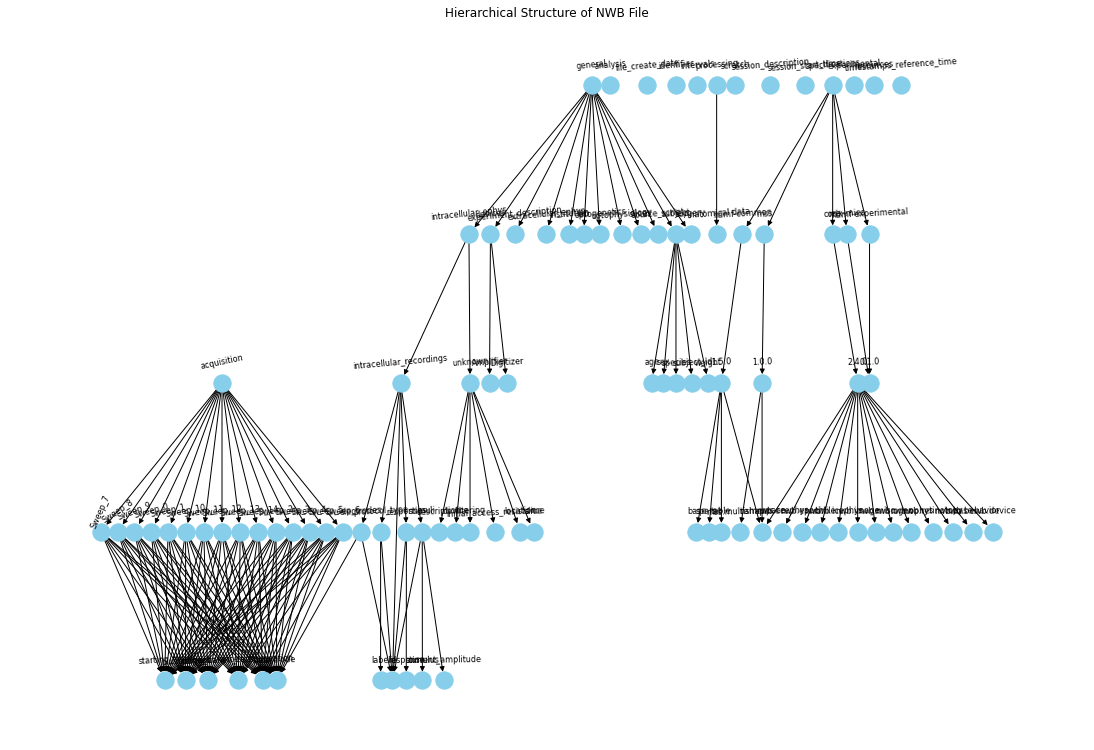

In [87]:
# Visualize the graph
draw_graph(graph)

In [ ]:
# Open the NWB file
with h5py.File(file_path, 'r') as file:
    # Find the path and value of sampling rate or rate recursively starting from the root
    sampling_rate_info = find_sampling_rate(file)
    print(file['acquisition']['Sweep_0']['starting_time'].attrs.keys())
    

if sampling_rate_info:
    path, rate = sampling_rate_info
    print(f"Sampling rate or rate found at path '{path}': {rate}")
else:
    print("No sampling rate or rate key/value found in the NWB file.")
#I checked and this is the sampling rate for all recordings

### Get the patch data, examine and filter

In [ ]:


def visualize_hdf5_data(file_path):
    # Open the HDF5 file
    with h5py.File(file_path, 'r') as f:
        # Initialize an empty list to store data arrays
        data = []

        # Iterate through keys in the 'acquisition' group
        for sweep_key in f['acquisition'].keys():
            dataset = f['acquisition'][sweep_key]['data'] 
            # Convert the dataset data into a NumPy array and append to the list
            data.append(np.array(dataset))

        # Convert the list of arrays into a NumPy array
        data = np.array(data)

        # Plot the data
        
        for i in range(len(data)):
            plt.plot(data[i])
        plt.xlabel('time (ms)')
        plt.ylabel('mV')
        plt.title('1D Dataset Visualization')
        plt.show()

        return data

# Example usage:
#file_path = 'your_file.h5'
data = visualize_hdf5_data(file_path)
data

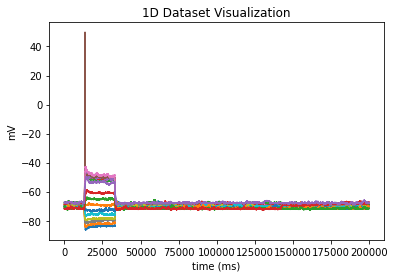

In [44]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def visualize_hdf5_data(file_path):
    # Open the HDF5 file
    with h5py.File(file_path, 'r') as f:
        # Initialize an empty list to store data arrays
        data = []

        # Iterate through keys in the 'acquisition' group
        for sweep_key in f['acquisition'].keys():
            dataset = f['acquisition'][sweep_key]['data'] 
            # Convert the dataset data into a NumPy array and append to the list
            data.append(np.array(dataset))

        # Plot the data
        if all(d.ndim == 1 for d in data):
            for d in data:
                plt.plot(d)
            plt.xlabel('time (ms)')
            plt.ylabel('mV')
            plt.title('1D Dataset Visualization')
            plt.show()
        elif all(d.ndim == 2 for d in data):
            for d in data:
                plt.imshow(d, cmap='viridis')
                plt.colorbar()
                plt.xlabel('X-axis')
                plt.ylabel('Y-axis')
                plt.title('2D Dataset Visualization')
                plt.show()
        else:
            print("Cannot visualize data with more than 2 dimensions.")

        return data

# Example usage:
data = visualize_hdf5_data(file_path)
